# Happiness Rank of Germany and Its Neighbors (2015–2019)

This notebook loads the World Happiness Report CSV files for 2015–2019 and plots the happiness rank of Germany and its neighboring countries over time.

**Schema normalization across years:**
| Year | Country column | Rank column |
|------|---------------|-------------|
| 2015/2016 | `Country` | `Happiness Rank` |
| 2017 | `Country` | `Happiness.Rank` |
| 2018/2019 | `Country or region` | `Overall rank` |

All DataFrames are normalized to `Country` and `Rank` before concatenation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline

In [2]:
COUNTRIES = [
    "Germany",
    "Denmark",
    "Poland",
    "Czech Republic",
    "Austria",
    "Switzerland",
    "France",
    "Luxembourg",
    "Belgium",
    "Netherlands",
]

YEAR_FILES = {
    2015: "2015.csv",
    2016: "2016.csv",
    2017: "2017.csv",
    2018: "2018.csv",
    2019: "2019.csv",
}


def load_year(year, filename):
    df = pd.read_csv(filename)

    # Normalize country column
    if "Country or region" in df.columns:
        df = df.rename(columns={"Country or region": "Country"})

    # Normalize rank column
    if "Happiness Rank" in df.columns:
        df = df.rename(columns={"Happiness Rank": "Rank"})
    elif "Happiness.Rank" in df.columns:
        df = df.rename(columns={"Happiness.Rank": "Rank"})
    elif "Overall rank" in df.columns:
        df = df.rename(columns={"Overall rank": "Rank"})

    df["Year"] = year
    return df[["Country", "Rank", "Year"]]


frames = [load_year(year, fname) for year, fname in YEAR_FILES.items()]
data = pd.concat(frames, ignore_index=True)

available = [c for c in COUNTRIES if c in data["Country"].values]
data = data[data["Country"].isin(available)]

pivot = data.pivot(index="Year", columns="Country", values="Rank")
pivot

Country,Austria,Belgium,Czech Republic,Denmark,France,Germany,Luxembourg,Netherlands,Poland,Switzerland
Year,,,,,,,,,,
2015,13,19,31,3,29,26,17,7,60,1
2016,12,18,27,1,32,16,20,7,57,2
2017,13,17,23,2,31,16,18,6,46,4
2018,12,16,21,3,23,15,17,6,42,5
2019,10,18,20,2,24,17,14,5,40,6


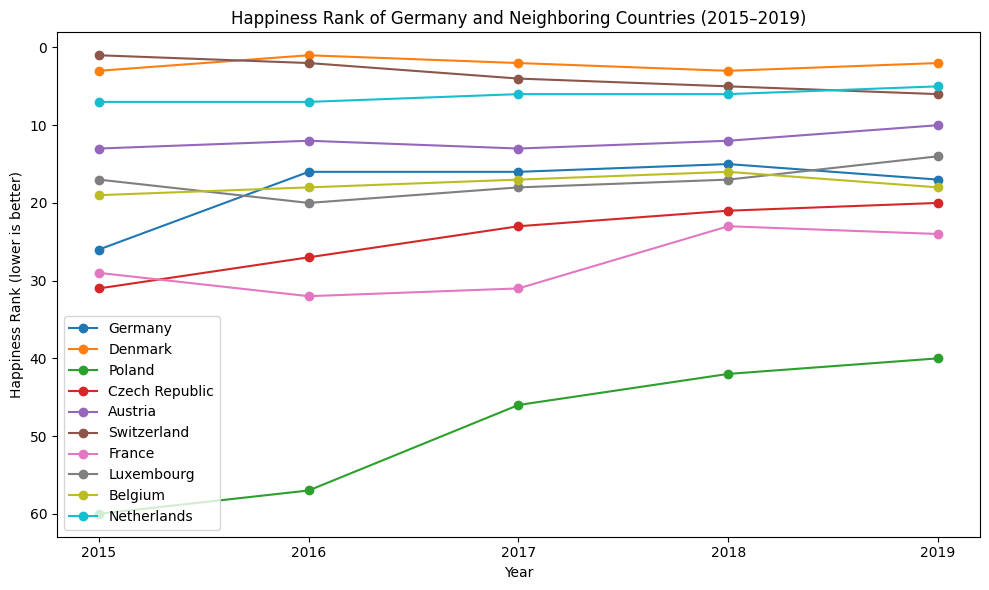

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for country in available:
    if country in pivot.columns:
        ax.plot(pivot.index, pivot[country], marker="o", label=country)

ax.invert_yaxis()  # Lower rank number = happier, so rank 1 is at the top
ax.set_xlabel("Year")
ax.set_ylabel("Happiness Rank (lower is better)")
ax.set_title("Happiness Rank of Germany and Neighboring Countries (2015–2019)")
ax.legend(loc="best")
ax.set_xticks(list(YEAR_FILES.keys()))

plt.tight_layout()
plt.savefig("happiness_rank.png", dpi=150)
plt.show()